In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

class BatchReactorEnv:
    """
    A class to simulate the environment of a batch reactor.

    This class encapsulates the state of the reactor, the physical model,
    and the methods to interact with the simulation (step and reset).
    This version is optimized for use in a Jupyter/Python notebook.
    """
    def __init__(self, data_path=r"C:\Users\Anushka\Downloads\Trajectory2.csv", dt=0.5, initial_history_size=50):
        """
        Initializes the batch reactor environment.

        Args:
            data_path (str): The path to the CSV file containing initial temperature data.
            dt (float): The time step for the simulation in minutes. This is not to be changed.
            initial_history_size (int): The number of initial data points to load. This is not to be changed.
        """

        # --- Physical and Chemical Constants ---
        self.Ad = 4.4e16
        self.Ed = 140.06e3
        self.Ap = 1.7e11 / 60
        self.Ep = 16.9e3 / 0.239
        self.deltaHp = -82.2e3
        self.UA = 33.3083
        self.V = 0.5
        self.Tc = 27.0
        self.Cpc = 4.184
        self.R = 8.3145
        self.alpha = 1.212827
        self.beta1 = 0.000267
        self.epsilon = 0.5
        self.theta = 1.25
        self.m1 = 450.0
        self.cp1 = 4.184
        self.mjCpj = (18 * 4.184) + (240 * 0.49)
        self.cp2 = 187.0
        self.cp3 = 110.58
        self.cp4 = 84.95
        self.m5 = 220.0
        self.cp5 = 0.49
        self.m6 = 7900.0
        self.cp6 = 0.49
        self.M0 = 0.7034
        self.I0 = 4.5e-3
        self.Qs = 12.41e-2

        # --- Simulation Parameters ---
        self.dt = dt
        self.initial_history_size = initial_history_size
        
        # --- Load Initial Data ---
        try:
            self.df = pd.read_csv(data_path)
        except FileNotFoundError:
            print(f"Error: The file '{data_path}' was not found.")
            print("Please ensure the CSV file is in the correct directory.")
            # Create a dummy dataframe to allow the script to run
            self.df = pd.DataFrame({
                'Jacket Temperature': np.linspace(80, 85, 100),
                'Reactor Temperature': np.linspace(90, 95, 100)
            })

        # --- State Initialization ---
        self.state_history = None
        self.reset()

    def get_state(self, current_step):
    # The 'State' is what the AI sees: [Actual Tr, Actual Tj, Target Tr]
        target_Tr = self.df['x_Traject'].iloc[current_step]
        current_state = self.state_history[-1] # [I, M, Tr, Tj]
        # Normalize values (VERY IMPORTANT)
        #Tr = current_state[2] / 100.0
        #Tj = current_state[3] / 100.0
        #target = target_Tr / 100.0
        return np.array([current_state[2]/100.0, current_state[3]/100.0, target_Tr/100.0], dtype=np.float32)

    def calculate_reward(self, next_Tr, current_step):  
    # Reward based on tracking error (Equation 9 logic)
        target_Tr = self.df['x_Traject'].iloc[current_step]
        error = abs(target_Tr - next_Tr)
        return -error  # Negative reward: the AI wants to stay close to 0 error


    def _normalize_heater_current(self, current_mA):
        """
        Normalizes the heater current (4-20mA) to power (0-1500W).
        
        Args:
            current_mA (float): The heater current in mA.
        
        Returns:
            float: The corresponding power in Watts.
        """
        min_current = 4.0   # mA
        max_current = 20.0  # mA
        min_power = 0.0     # watts
        max_power = 1500.0  # watts

        # Clamp the current to the valid range
        current_mA = np.clip(current_mA, min_current, max_current)

        normalized_power = ((current_mA - min_current) / (max_current - min_current)) * (max_power - min_power) + min_power
        return normalized_power

    def _BR_plant(self, t, X0, F, Hc):
        """
        Defines the system of differential equations for the batch reactor.

        Args:
            t (float): Time (not used directly, but required by solve_ivp).
            X0 (list or np.array): The current state vector [I, M, Tr, Tj].
            F (float): Coolant flow rate (u1).
            Hc (float): Heater current in mA (u2).

        Returns:
            list: The derivatives of the state variables [dI/dt, dM/dt, dTr/dt, dTj/dt].
        """
        # Unpack state variables
        I, M, Tr, Tj = X0

        # Convert coolant flow rate to appropriate units
        F_conv = F * 16.667
        
        # Calculate heat from heater
        Qc_val = self._normalize_heater_current(Hc)

        # Reaction rates
        k_d = self.Ad * np.exp(-self.Ed / (self.R * (Tr + 273.15)))
        k_p = self.Ap * np.exp(-self.Ep / (self.R * (Tr + 273.15)))
        
        Ri = k_d * I
        Rp = k_p * (I ** self.epsilon) * (M ** self.theta)

        # Heat capacity and heat generation/absorption
        mrCpr = (self.m1 * self.cp1 + I * self.cp2 * self.V + M * self.cp3 * self.V +
                 (self.M0 - M) * self.cp4 * self.V + self.m5 * self.cp5 + self.m6 * self.cp6)
        
        Qpr = self.alpha * (Tr - self.Tc) ** self.beta1

        # Differential equations
        dI_dt = -Ri
        dM_dt = -Rp
        dTr_dt = (Rp * self.V * (-self.deltaHp) - self.UA * (Tr - Tj) + Qc_val + self.Qs - Qpr) / mrCpr
        dTj_dt = (self.UA * (Tr - Tj) - F_conv * self.Cpc * (Tj - self.Tc)) / self.mjCpj
        
        return [dI_dt, dM_dt, dTr_dt, dTj_dt]

    def reset(self):
        """
        Resets the environment to its initial state.
        
        Initializes the state history with values from the provided CSV file.

        Returns:
            np.array: The initial state of the environment (last row of the initial history).
        """
        t = self.initial_history_size
        self.state_history = np.zeros((t, 4))
        
        # Initial Initiator Concentration
        self.state_history[:, 0] = 4.5e-5 
        # Initial Monomer Concentration
        self.state_history[:, 1] = 0.7034
        # Initial Jacket Temperature from data
        self.state_history[:, 3] = self.df['x_Traject'].values[:t]
        # Initial Reactor Temperature from data
        self.state_history[:, 2] = self.df['x_Traject'].values[:t]
        
        # Return the last known state as the current state
        return self.state_history[-1]

    def step(self, u1, u2):
        """
        Advances the simulation by one time step.

        Args:
            u1 (float): The coolant flow rate, F.
            u2 (float): The heater current in mA, Hc.

        Returns:
            tuple: A tuple containing the next reactor temperature (Tr) 
                   and the next jacket temperature (Tj).
        """
        # Get the last known state
        current_state = self.state_history[-1]
        
        # Integrate the differential equations over one time step
        solution = solve_ivp(
            self._BR_plant, 
            [0, self.dt], 
            current_state, 
            method='RK45', 
            args=(u1, u2)
        )
        
        # The output is the state at the end of the time step
        next_state = solution.y[:, -1]
        
        # Append the new state to the history
        self.state_history = np.vstack((self.state_history, next_state))
        
        # Extract the temperatures to be returned
        next_Tr = next_state[2]
        next_Tj = next_state[3]
        
        return next_Tr, next_Tj
    


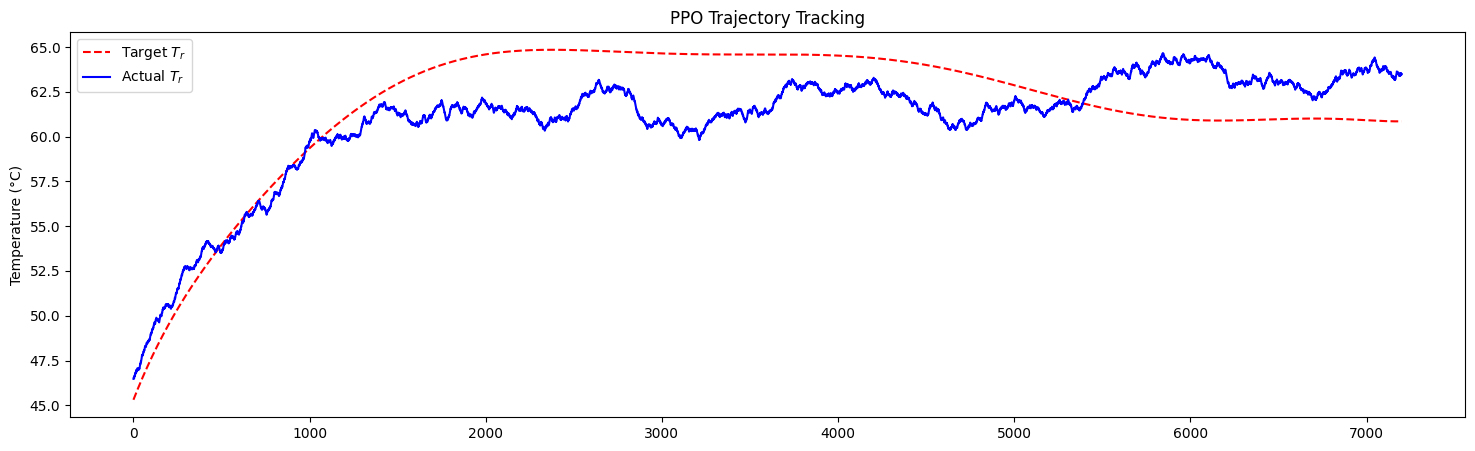

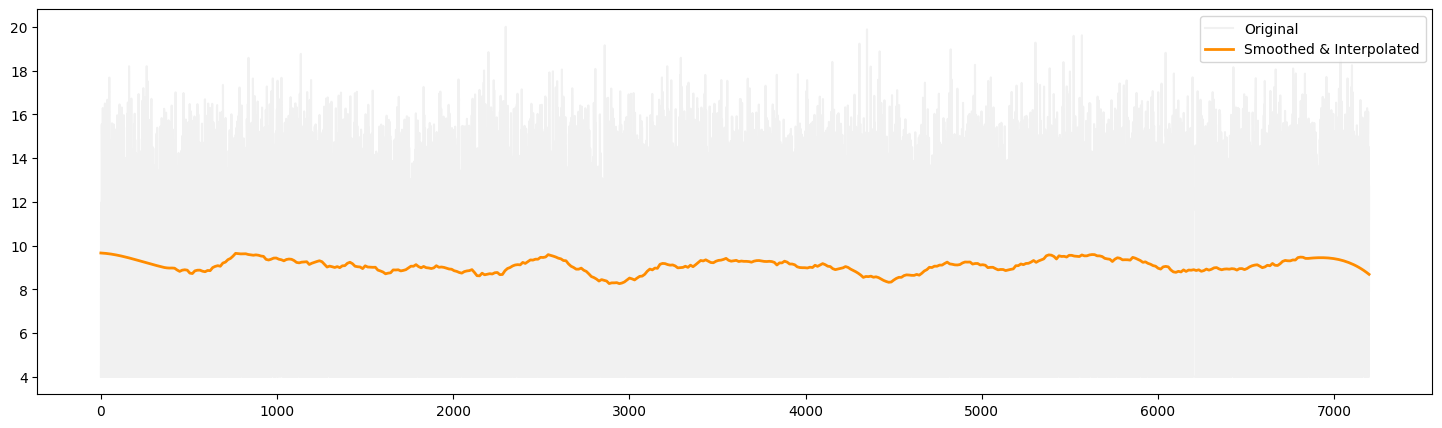

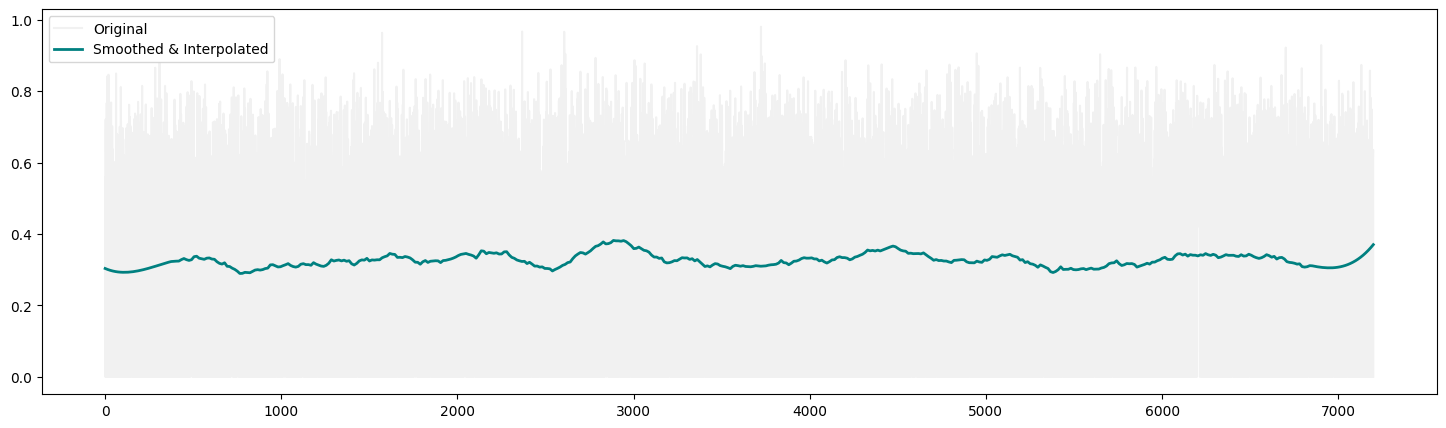

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import make_interp_spline
from scipy.signal import savgol_filter

# --- Neural Network Architecture ---
class ActorCritic(nn.Module):
    action_dim=2
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.log_std = nn.Parameter(torch.ones(1, action_dim) *-1.5)
        
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, state):
        value = self.critic(state)
        mu = self.actor(state)
        std = torch.exp(self.log_std)
        dist = Normal(mu, std)
        return dist, value

# --- PPO Agent ---
class PPOAgent:
    def __init__(self, state_dim, action_dim):
        self.gamma = 0.99
        self.eps_clip = 0.2
        self.lr = 3e-4
        
        self.policy = ActorCritic(state_dim, action_dim)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=self.lr)
        self.policy_old = ActorCritic(state_dim, action_dim)
        self.policy_old.load_state_dict(self.policy.state_dict())
        
        self.mse_loss = nn.MSELoss()

    def select_action(self, state):
        with torch.no_grad():
            state = torch.FloatTensor(state)
            dist, _ = self.policy_old(state)
            action = dist.sample()
            action_logprob = dist.log_prob(action).sum(dim=-1)
        return action.numpy(), action_logprob.item()

    def update(self, memory):
        # Using np.stack to ensure consistent array shape for tensors
        states = torch.FloatTensor(np.stack(memory['states']))
        actions = torch.FloatTensor(np.stack(memory['actions']))
        old_logprobs = torch.FloatTensor(np.array(memory['logprobs']))
        
        # Calculate Returns
        returns = []
        discounted_reward = 0
        for reward in reversed(memory['rewards']):
            discounted_reward = reward + (self.gamma * discounted_reward)
            returns.insert(0, discounted_reward)
        returns = torch.FloatTensor(returns)
        

        # Optimization loop (PPO Epochs)
        for _ in range(50):
            dist, state_values = self.policy(states)
            new_logprobs = dist.log_prob(actions).sum(dim=-1)
            
            # Equation 1: Probability Ratio rt(theta)
            ratio = torch.exp(new_logprobs / old_logprobs)
            
            # Equation 4: Advantage Estimation At
            #advantages = returns - state_values.detach().squeeze()
            advantages = (returns - state_values.detach().squeeze())
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            
            # Equation 2: Clipped Surrogate Objective L_CLIP
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
            
            # Equation 3: Combined Loss (Policy + Value)
            loss = -torch.min(surr1, surr2).mean() + 0.5 * self.mse_loss(state_values.squeeze(), returns)
            
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
        
        self.policy_old.load_state_dict(self.policy.state_dict())

# --- Setup and Execution ---
state_dim = 3
action_dim = 2
env = BatchReactorEnv()
agent = PPOAgent(state_dim, action_dim)


def map_action_exclusive(action):
    a = np.array(action).flatten() # Resolves shape issues
    
    # a[0] = Coolant intent, a[1] = Heater intent
    # Winner-takes-all logic makes them perfect opposites
    if a[1] > a[0]: 
        u1 = 0.0                      # Coolant OFF
        u2 = np.clip((a[1] + 1) * 8 + 4, 4, 20) # Heater 4-20mA
    else:
        u1 = np.clip((a[0] + 1) * 0.5, 0, 1)    # Coolant 0-1 L/min
        u2 = 4.0                      # Heater MIN
    return u1, u2

# Store data for visualization
history = {'target': [], 'actual': [], 'u1': [], 'u2': []}
memory = {'states': [], 'actions': [], 'logprobs': [], 'rewards': []}

# Running Simulation (Reduced step count for demonstration stability)
env.reset()
for step in range(0, 7200): # Adjust range as needed for your CSV length
    state = env.get_state(step)
    action, logprob = agent.select_action(state)

    #if step > 0 and step % 2000 == 0:
     #   agent.update(memory)
      #  # Clear memory after update to start fresh for the next batch
       # memory = {'states': [], 'actions': [], 'logprobs': [], 'rewards': []}

    u1, u2 = map_action_exclusive(action)
    next_Tr, next_Tj = env.step(u1, u2)
    reward = env.calculate_reward(next_Tr, step)
    
    # Store for training (must use sample)
    memory['states'].append(state)
    memory['actions'].append(action)
    memory['logprobs'].append(logprob)
    memory['rewards'].append(reward)
    
    # Store for plotting (must use plot values)
    history['target'].append(env.df['x_Traject'].iloc[step])
    history['actual'].append(next_Tr)
    history['u1'].append(u1) # This creates the smooth line
    history['u2'].append(u2) # This creates the smooth line

# --- Updated Visualization: Tracking and Individual Control Signals ---
fig, (ax1) = plt.subplots(1, 1, figsize=(18, 5))

# Subplot 1: Reactor Temperature Tracking
ax1.plot(history['target'], 'r--', label='Target $T_r$')
ax1.plot(history['actual'], 'b-', label='Actual $T_r$')
ax1.set_title('PPO Trajectory Tracking')
ax1.set_ylabel('Temperature (°C)')
ax1.legend()

#VISUALIZATION
stride=1
indices=np.arange(len(history['u1']))[::stride]


data_slice = np.array(history['u2'])[::stride]

# Calculate window size (e.g., 10% of data), but ensure it's at least 5 and odd
w_size = max(5, int(len(data_slice) * 0.1))
if w_size % 2 == 0: w_size += 1 
u2_smooth = savgol_filter(np.array(history['u2'])[::stride], window_length=w_size, polyorder=3)
u1_smooth=savgol_filter(np.array(history['u1'])[::stride], window_length=w_size, polyorder=3)

# 1. Create a much denser x-axis (e.g., 500 points instead of 30)
indices_new = np.linspace(indices.min(), indices.max(), 500)

# 2. Use a Cubic Spline (k=3) to interpolate between your smoothed values
spline = make_interp_spline(indices, u2_smooth, k=3)
u2_extra_smooth = spline(indices_new)
spline = make_interp_spline(indices, u1_smooth, k=3)
u1_extra_smooth = spline(indices_new)

# 3. Plot the high-res version

# Subplot 2: Control Signal 1 (Coolant Flow)
plt.figure(figsize=(18, 5))
plt.plot(indices, np.array(history['u2'])[::stride], 'lightgray', label='Original', alpha=0.3)
plt.plot(indices_new, u2_extra_smooth, 'darkorange', label='Smoothed & Interpolated', linewidth=2)
plt.legend()
plt.show()

# Subplot 3: Control Signal 2 (Heater Current)
plt.figure(figsize=(18, 5))
plt.plot(indices, np.array(history['u1'])[::stride], 'lightgray', label='Original', alpha=0.3)
plt.plot(indices_new, u1_extra_smooth, 'teal', label='Smoothed & Interpolated', linewidth=2)
plt.legend()
plt.show()

